In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append(f"./../")
from src.graphs import StaticGraph, DynamicGraph
from qiskit.quantum_info import Statevector, Operator, state_fidelity
from scipy.linalg import expm
import matplotlib.pyplot as plt
import numpy as np

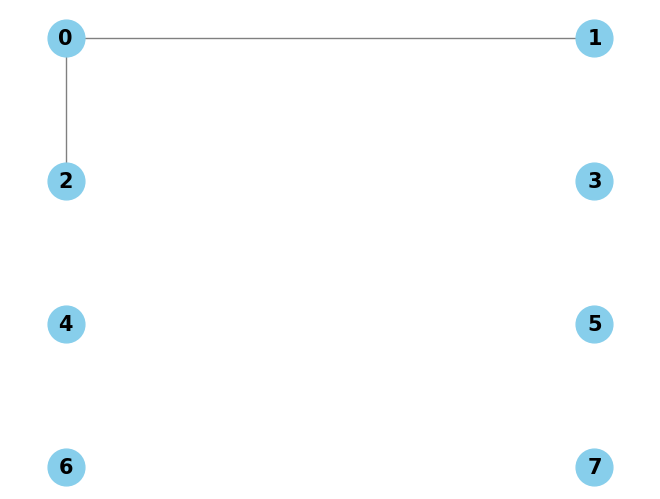

In [2]:
edges = {('000','010'),
         ('000','001')}

G = StaticGraph(edges)
G.draw()

In [3]:
T = 1000
graph_sequence = [(G, T)]
dyn_G = DynamicGraph(graph_sequence)

In [4]:
psi_0 = Statevector.from_label('0'*G.n_qubits)
print('Initial State: ')
psi_0.draw('latex')

Initial State: 


<IPython.core.display.Latex object>

In [5]:
time_evo_op = dyn_G.time_evo_op()
print('Exact Time Evolution Operator: ')
time_evo_op.draw('latex')

Exact Time Evolution Operator: 


<IPython.core.display.Latex object>

In [6]:
psi_target = psi_0.evolve(time_evo_op)
print('Target (Exact) State: ')
psi_target.draw('latex')

Target (Exact) State: 


<IPython.core.display.Latex object>

StaticGraph({('000', '010')}) | Time = 0.1


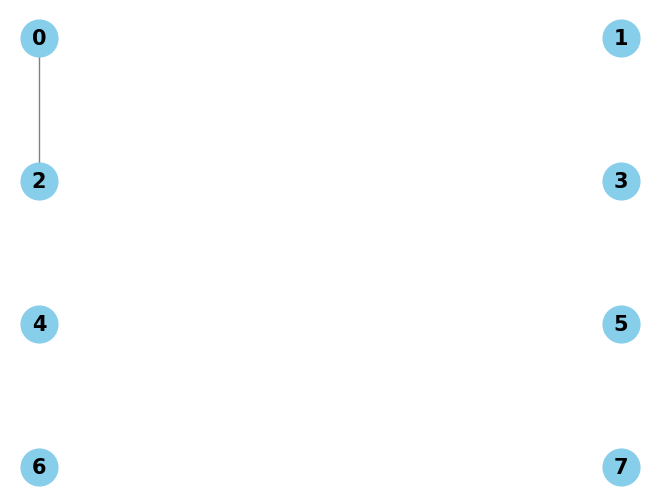

StaticGraph({('000', '001')}) | Time = 0.1


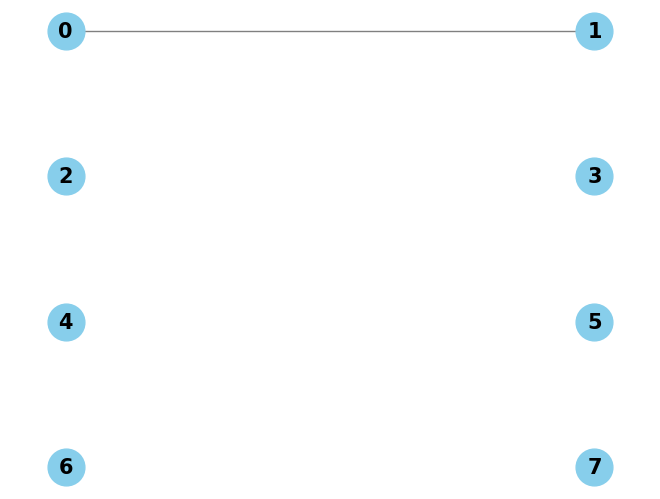

In [7]:
edges1 = {('000','010')}
edges2 = {('000','001')}

G1 = StaticGraph(edges1)
G2 = StaticGraph(edges2)

delta_t = 0.1
t_steps = int(T/delta_t)

graph_sequence = [(G1, delta_t), (G2, delta_t)] 
dyn_G = DynamicGraph(graph_sequence)
dyn_G.draw()

In [8]:
time_evo_op = dyn_G.time_evo_op(t_steps=t_steps)
print('Approximated Time Evolution Operator: ')
time_evo_op.draw('latex')

Approximated Time Evolution Operator: 


<IPython.core.display.Latex object>

In [9]:
psi_out = psi_0.evolve(time_evo_op)
print('Output (Approximated) State: ')
psi_out.draw('latex')

Output (Approximated) State: 


<IPython.core.display.Latex object>

In [10]:
fid = state_fidelity(psi_out, psi_target)
infid = 1 - fid

print(f'State Infidelity (Difference between Exact State and Approximated State): {round(infid, 3)}')

State Infidelity (Difference between Exact State and Approximated State): 0.084
